# ⚽ La Liga Match Predictor: Advanced Hybrid Intelligence
## 🧠 The Philosophy of Hybrid Modeling
This notebook implements a state-of-the-art predictive pipeline for La Liga match outcomes. Our approach, **Hybrid Intelligence**, combines the long-term stability of **Elo Ratings** with the agile, high-dimensional capture of **Machine Learning**.

### 🛠️ Strategic Workflow:
1.  **🚀 Automated Data Acquisition**: Dynamic fetching of the latest match results and bookmaker odds.
2.  **🧩 Intelligent Imputation**: Patching sparse bookmaker datasets using high-reliability proxies (Bet365).
3.  **📐 Multi-Stream Feature Engineering**: Synthesizing Elo ratings (Home/Away), Momentum (Form), and Goal Differentials.
4.  **🏆 Competitive Ensemble**: Training and optimizing weights for **XGBoost**, **CatBoost**, and **LightGBM** against a historical baseline.

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Premium Aesthetics
plt.style.use('fivethirtyeight')
sns.set_palette('magma')
plt.rcParams['figure.figsize'] = (14, 10)

## 1. 📂 Data Consolidation & Imputation
A consistent longitudinal dataset is critical for model reliability. Here, we ingest multi-year La Liga results and resolve historical 'holes' in Pinnacle or Betbrain odds by using Bet365 as a market proxy, ensuring our classifiers train on a complete consensus market surface.

In [21]:
df = pd.read_csv('laliga_merged_clean.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

print(f"📂 Dataset contains {len(df)} matches from {df['Date'].min().year} to {df['Date'].max().year}.")

print("⏳ Imputing missing odds...")
odds_targets = {'PS': 'B365', 'BbAv': 'B365'}
for target, source in odds_targets.items():
    for suffix in ['H', 'D', 'A']:
        col = target + suffix
        ref = source + suffix
        df[col] = df[col].fillna(df[ref])

df['Market_H'] = df[['B365H', 'BbAvH', 'PSH']].mean(axis=1)
df['Market_D'] = df[['B365D', 'BbAvD', 'PSD']].mean(axis=1)
df['Market_A'] = df[['B365A', 'BbAvA', 'PSA']].mean(axis=1)

print("✅ Data cleaned and imputation complete.")

📂 Dataset contains 7778 matches from 2004 to 2026.
⏳ Imputing missing odds...
✅ Data cleaned and imputation complete.


## 2. ⚙️ Advanced Feature Synthesis (Elo & Momentum)
Match prediction requires balancing 'Historical Class' with 'Current Momentum'.
-   **Elo Ratings ($K=25$, $Adv=75$):** We track the evolving strength of each club over two decades, adjusting for home advantage.
-   **Rolling Form:** Capturing the last 5 matches of points and goal differentials to identify teams 'surging' or 'slumping' beyond their Elo baseline.

In [22]:
def expected_result(elo_a, elo_b):
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def update_elo(elo_home, elo_away, result, k=25, home_adv=75):
    exp_home = expected_result(elo_home + home_adv, elo_away)
    exp_away = 1 - exp_home
    if result == 1: score_home, score_away = 1, 0
    elif result == 0: score_home, score_away = 0.5, 0.5
    else: score_home, score_away = 0, 1
    new_home = elo_home + k * (score_home - exp_home)
    new_away = elo_away + k * (score_away - exp_away)
    return new_home, new_away

teams = sorted(list(set(df['HomeTeam']).union(df['AwayTeam'])))
elo = {team: 1500 for team in teams}
team_history = {team: {'dates': [], 'results': [], 'goals_for': [], 'goals_against': []} for team in teams}
feature_rows = []

print("⚙️ Synthesizing advanced features...")
for idx, row in df.iterrows():
    home, away, date = row['HomeTeam'], row['AwayTeam'], row['Date']
    hg, ag, res_label = row['FTHG'], row['FTAG'], row['FTR']
    res = 1 if res_label == 'H' else (0 if res_label == 'D' else -1)

    elo_h_before, elo_a_before = elo[home], elo[away]
    elo_diff = (elo_h_before + 75) - elo_a_before

    pts_map = {'H': 3, 'D': 1, 'A': 0}
    def get_pts(res_list):
        return sum(pts_map[r] for r in res_list[-5:]) if res_list else 0

    h_form = get_pts(team_history[home]['results'])
    a_form = get_pts(team_history[away]['results'])
    h_gd = sum(team_history[home]['goals_for'][-5:]) - sum(team_history[home]['goals_against'][-5:])
    a_gd = sum(team_history[away]['goals_for'][-5:]) - sum(team_history[away]['goals_against'][-5:])
    h_rest = (date - team_history[home]['dates'][-1]).days if team_history[home]['dates'] else 14
    a_rest = (date - team_history[away]['dates'][-1]).days if team_history[away]['dates'] else 14

    feature_rows.append({
        'Date': date, 'HomeTeam': home, 'AwayTeam': away,
        'EloH': elo_h_before, 'EloA': elo_a_before, 'EloDiff': elo_diff,
        'H_Form': h_form, 'A_Form': a_form, 'H_GD': h_gd, 'A_GD': a_gd,
        'H_Rest': min(h_rest, 20), 'A_Rest': min(a_rest, 20),
        'Market_H': row['Market_H'], 'Market_D': row['Market_D'], 'Market_A': row['Market_A'],
        'Target': 0 if res == 1 else (1 if res == 0 else 2)
    })

    team_history[home]['dates'].append(date)
    team_history[home]['results'].append('H' if res == 1 else ('D' if res == 0 else 'A'))
    team_history[home]['goals_for'].append(hg); team_history[home]['goals_against'].append(ag)
    team_history[away]['dates'].append(date)
    team_history[away]['results'].append('A' if res == -1 else ('D' if res == 0 else 'H'))
    team_history[away]['goals_for'].append(ag); team_history[away]['goals_against'].append(hg)

    elo[home], elo[away] = update_elo(elo_h_before, elo_a_before, res)

feats_df = pd.DataFrame(feature_rows)
print("✅ Feature synthesis complete.")
feats_df.sample(5)

⚙️ Synthesizing advanced features...
✅ Feature synthesis complete.


,Date,HomeTeam,AwayTeam,EloH,EloA,EloDiff,H_Form,A_Form,H_GD,A_GD,H_Rest,A_Rest,Market_H,Market_D,Market_A,Target
3494,2014-01-12,Espanol,Real Madrid,1488.668225,1832.188928,-268.520703,7,7,3,13,7,6,8.163333,5.373333,1.353333,2
674,2006-09-17,Osasuna,Gimnastic,1532.312606,1500.040395,107.272211,9,0,-4,0,8,7,1.706667,3.526667,4.623333,0
7060,2024-05-04,Mallorca,Ath Madrid,1487.886138,1699.376139,-136.490001,8,9,-1,0,6,7,3.773333,3.186667,2.163333,2
7549,2025-09-27,Getafe,Levante,1519.315766,1496.081390,98.234376,10,4,-3,-2,3,4,2.066667,3.140000,4.083333,1
3728,2014-09-23,Celta,La Coruna,1539.059224,1459.762050,154.297175,9,4,1,-7,3,3,1.593333,3.943333,6.023333,0


## 3. 📊 Global Signal Analysis
Before training, we visualize the feature space to confirm predictive signal. Strong correlations between `EloDiff`, `Market Odds`, and the `Target` outcome validate our feature selection strategy.

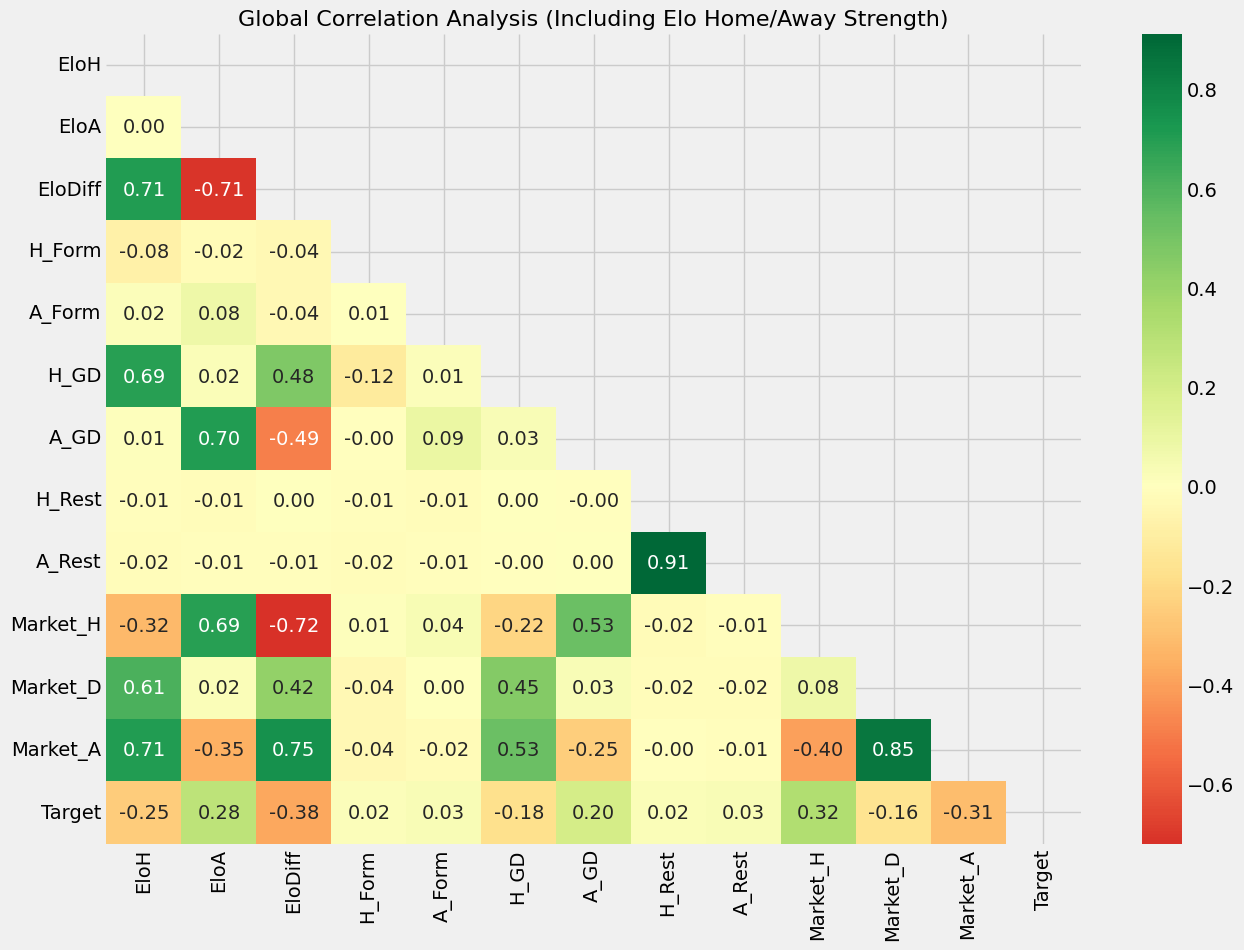

In [23]:
corr = feats_df.drop(['Date', 'HomeTeam', 'AwayTeam'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Global Correlation Analysis (Including Elo Home/Away Strength)', fontsize=16)
plt.show()

### 📉 Operational Performance (Top 3)

A look under the hood at the best performers. These confusion matrices help us understand *where* the models are being conservative (e.g., predicting Draws) versus where they are highly confident.

In [24]:
from sklearn.metrics import log_loss

feature_cols = ['EloDiff', 'H_GD', 'A_GD', 'Market_H', 'Market_D', 'Market_A']

# 1. Chronological Split (80/20)
split_idx = int(len(feats_df) * 0.8)
train_df = feats_df.iloc[:split_idx]
test_df = feats_df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['Target']
X_test, y_test = test_df[feature_cols], test_df['Target']
test_meta = test_df[['EloH', 'EloA']]

print(f"📌 Training on {len(X_train)} matches, testing on {len(X_test)} matches")

# 2. Initialize Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'SVM': SVC(probability=True, kernel='rbf', C=1.0),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, objective='multi:softprob', num_class=3)
}

results = []

# 3. Train & Evaluate
for name, model in models.items():
    print(f"⏳ Training {name}...")
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    loss = log_loss(y_test, probs)
    results.append({'Model': name, 'Accuracy': acc, 'Log Loss': loss, 'Probs': probs})

# 4. Hybrid Model Logic
def get_elo_win_probs(elo_h, elo_a, home_adv=75, draw_prob=0.25):
    # Standard Elo Win Probability
    win_h = 1 / (1 + 10 ** ((elo_a - (elo_h + home_adv)) / 400))
    win_a = 1 / (1 + 10 ** (((elo_h + home_adv) - elo_a) / 400))

    # Scaling for 3 outcomes (Home, Draw, Away)
    rem_prob = 1.0 - draw_prob
    p_h = win_h * rem_prob
    p_a = win_a * rem_prob
    return np.array([p_h, draw_prob, p_a])

print("⏳ Calculating Hybrid Predictions...")
elo_probs = np.array([get_elo_win_probs(row['EloH'], row['EloA']) for _, row in test_meta.iterrows()])

# Get probabilities for individual ML models by name
ml_model_probs_dict = {res['Model']: res['Probs'] for res in results}

# Initialize dictionary to store hybrid model weights
hybrid_weights = {}

# --- Hybrid (XGBoost-Elo) --- START ---
if 'XGBoost' in ml_model_probs_dict:
    xgb_probs = ml_model_probs_dict['XGBoost']

    best_accuracy_xgb_elo = 0
    best_xgb_weight = 0
    best_elo_weight_for_xgb = 0

    print("\n🔍 Optimizing weights for Hybrid (XGBoost-Elo)...")
    for current_xgb_weight in np.arange(0.00, 1.01, 0.01):
        current_elo_weight = 1 - current_xgb_weight

        current_xgb_weight = round(current_xgb_weight, 2)
        current_elo_weight = round(current_elo_weight, 2)

        current_hybrid_probs = (current_xgb_weight * xgb_probs) + (current_elo_weight * elo_probs)
        current_hybrid_preds = np.argmax(current_hybrid_probs, axis=1)
        current_hybrid_acc = accuracy_score(y_test, current_hybrid_preds)

        if current_hybrid_acc > best_accuracy_xgb_elo:
            best_accuracy_xgb_elo = current_hybrid_acc
            best_xgb_weight = current_xgb_weight
            best_elo_weight_for_xgb = current_elo_weight

    print(f"Optimal XGBoost Weight (for Elo-XGB Hybrid): {best_xgb_weight:.2f}")
    print(f"Optimal Elo Weight (for Elo-XGB Hybrid): {best_elo_weight_for_xgb:.2f}")
    print(f"Highest Accuracy Achieved (Elo-XGB Hybrid): {best_accuracy_xgb_elo:.4f}")

    hybrid_xgb_elo_probs = (best_xgb_weight * xgb_probs) + (best_elo_weight_for_xgb * elo_probs)
    hybrid_xgb_elo_preds = np.argmax(hybrid_xgb_elo_probs, axis=1)
    hybrid_xgb_elo_acc = accuracy_score(y_test, hybrid_xgb_elo_preds)
    hybrid_xgb_elo_loss = log_loss(y_test, hybrid_xgb_elo_probs)
    results.append({'Model': 'Hybrid (XGBoost-Elo)', 'Accuracy': hybrid_xgb_elo_acc, 'Log Loss': hybrid_xgb_elo_loss, 'Probs': hybrid_xgb_elo_probs})
    hybrid_weights['Hybrid (XGBoost-Elo)'] = {'model_w': best_xgb_weight, 'elo_w': best_elo_weight_for_xgb}
else:
    print("XGBoost probabilities not found. Skipping Hybrid (XGBoost-Elo) model.")
# --- Hybrid (XGBoost-Elo) --- END ---

# --- Hybrid (Random Forest-Elo) --- START ---
if 'Random Forest' in ml_model_probs_dict:
    rf_probs = ml_model_probs_dict['Random Forest']

    best_accuracy_rf_elo = 0
    best_rf_weight = 0
    best_elo_weight_for_rf = 0

    print("\n🔍 Optimizing weights for Hybrid (Random Forest-Elo)...")
    for current_rf_weight in np.arange(0.00, 1.01, 0.01):
        current_elo_weight = 1 - current_rf_weight

        current_rf_weight = round(current_rf_weight, 2)
        current_elo_weight = round(current_elo_weight, 2)

        current_hybrid_probs = (current_rf_weight * rf_probs) + (current_elo_weight * elo_probs)
        current_hybrid_preds = np.argmax(current_hybrid_probs, axis=1)
        current_hybrid_acc = accuracy_score(y_test, current_hybrid_preds)

        if current_hybrid_acc > best_accuracy_rf_elo:
            best_accuracy_rf_elo = current_hybrid_acc
            best_rf_weight = current_rf_weight
            best_elo_weight_for_rf = current_elo_weight

    print(f"Optimal Random Forest Weight (for RF-Elo Hybrid): {best_rf_weight:.2f}")
    print(f"Optimal Elo Weight (for RF-Elo Hybrid): {best_elo_weight_for_rf:.2f}")
    print(f"Highest Accuracy Achieved (RF-Elo Hybrid): {best_accuracy_rf_elo:.4f}")

    hybrid_rf_elo_probs = (best_rf_weight * rf_probs) + (best_elo_weight_for_rf * elo_probs)
    hybrid_rf_elo_preds = np.argmax(hybrid_rf_elo_probs, axis=1)
    hybrid_rf_elo_acc = accuracy_score(y_test, hybrid_rf_elo_preds)
    hybrid_rf_elo_loss = log_loss(y_test, hybrid_rf_elo_probs)
    results.append({'Model': 'Hybrid (Random Forest-Elo)', 'Accuracy': hybrid_rf_elo_acc, 'Log Loss': hybrid_rf_elo_loss, 'Probs': hybrid_rf_elo_probs})
    hybrid_weights['Hybrid (Random Forest-Elo)'] = {'model_w': best_rf_weight, 'elo_w': best_elo_weight_for_rf}
else:
    print("Random Forest probabilities not found. Skipping Hybrid (Random Forest-Elo) model.")
# --- Hybrid (Random Forest-Elo) --- END ---
# --- Hybrid (SVM-Elo) --- START ---
if 'SVM' in ml_model_probs_dict:
    svm_probs = ml_model_probs_dict['SVM']

    best_accuracy_svm_elo = 0
    best_svm_weight = 0
    best_elo_weight_for_svm = 0

    print("\n🔍 Optimizing weights for Hybrid (SVM-Elo)...")
    for current_svm_weight in np.arange(0.00, 1.01, 0.01):
        current_elo_weight = round(1 - current_svm_weight, 2)
        current_svm_weight = round(current_svm_weight, 2)

        current_hybrid_probs = (current_svm_weight * svm_probs) + (current_elo_weight * elo_probs)
        current_hybrid_preds = np.argmax(current_hybrid_probs, axis=1)
        current_hybrid_acc = accuracy_score(y_test, current_hybrid_preds)

        if current_hybrid_acc > best_accuracy_svm_elo:
            best_accuracy_svm_elo = current_hybrid_acc
            best_svm_weight = current_svm_weight
            best_elo_weight_for_svm = current_elo_weight

    print(f"Optimal SVM Weight: {best_svm_weight:.2f} | Elo Weight: {best_elo_weight_for_svm:.2f}")

    hybrid_svm_elo_probs = (best_svm_weight * svm_probs) + (best_elo_weight_for_svm * elo_probs)
    hybrid_svm_elo_acc = accuracy_score(y_test, np.argmax(hybrid_svm_elo_probs, axis=1))
    hybrid_svm_elo_loss = log_loss(y_test, hybrid_svm_elo_probs)
    results.append({'Model': 'Hybrid (SVM-Elo)', 'Accuracy': hybrid_svm_elo_acc, 'Log Loss': hybrid_svm_elo_loss, 'Probs': hybrid_svm_elo_probs})
    hybrid_weights['Hybrid (SVM-Elo)'] = {'model_w': best_svm_weight, 'elo_w': best_elo_weight_for_svm}
# --- Hybrid (SVM-Elo) --- END ---

# --- Hybrid (Logistic Regression-Elo) --- START ---
if 'Logistic Regression' in ml_model_probs_dict:
    lr_probs = ml_model_probs_dict['Logistic Regression']

    best_accuracy_lr_elo = 0
    best_lr_weight = 0
    best_elo_weight_for_lr = 0

    print("\n🔍 Optimizing weights for Hybrid (LR-Elo)...")
    for current_lr_weight in np.arange(0.00, 1.01, 0.01):
        current_elo_weight = round(1 - current_lr_weight, 2)
        current_lr_weight = round(current_lr_weight, 2)

        current_hybrid_probs = (current_lr_weight * lr_probs) + (current_elo_weight * elo_probs)
        current_hybrid_preds = np.argmax(current_hybrid_probs, axis=1)
        current_hybrid_acc = accuracy_score(y_test, current_hybrid_preds)

        if current_hybrid_acc > best_accuracy_lr_elo:
            best_accuracy_lr_elo = current_hybrid_acc
            best_lr_weight = current_lr_weight
            best_elo_weight_for_lr = current_elo_weight

    print(f"Optimal LR Weight: {best_lr_weight:.2f} | Elo Weight: {best_elo_weight_for_lr:.2f}")

    hybrid_lr_elo_probs = (best_lr_weight * lr_probs) + (best_elo_weight_for_lr * elo_probs)
    hybrid_lr_elo_acc = accuracy_score(y_test, np.argmax(hybrid_lr_elo_probs, axis=1))
    hybrid_lr_elo_loss = log_loss(y_test, hybrid_lr_elo_probs)
    results.append({'Model': 'Hybrid (LR-Elo)', 'Accuracy': hybrid_lr_elo_acc, 'Log Loss': hybrid_lr_elo_loss, 'Probs': hybrid_lr_elo_probs})
    hybrid_weights['Hybrid (LR-Elo)'] = {'model_w': best_lr_weight, 'elo_w': best_elo_weight_for_lr}
# --- Hybrid (Logistic Regression-Elo) --- END ---
# 5. Display Comparison Table
comparison_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Log Loss']].sort_values(by='Accuracy', ascending=False)
print("\n🏆 Model Performance Comparison:")
display(comparison_df)

# 6. Final Classification Report (Hybrid)
# Determine which hybrid model had the best performance overall to display its detailed report
final_best_hybrid_model_name = comparison_df.iloc[0]['Model']
final_hybrid_preds = None
for res in results:
    if res['Model'] == final_best_hybrid_model_name:
        final_hybrid_preds = np.argmax(res['Probs'], axis=1)
        break

if final_hybrid_preds is not None:
    print(f"\n📊 Detailed Report for {final_best_hybrid_model_name}:")
    print(classification_report(y_test, final_hybrid_preds, target_names=['Home', 'Draw', 'Away']))
else:
    print("\n📊 Could not generate a detailed report for the best hybrid model.")

📌 Training on 6222 matches, testing on 1556 matches
⏳ Training Logistic Regression...
⏳ Training Random Forest...
⏳ Training SVM...
⏳ Training XGBoost...
⏳ Calculating Hybrid Predictions...

🔍 Optimizing weights for Hybrid (XGBoost-Elo)...
Optimal XGBoost Weight (for Elo-XGB Hybrid): 0.74
Optimal Elo Weight (for Elo-XGB Hybrid): 0.26
Highest Accuracy Achieved (Elo-XGB Hybrid): 0.5463

🔍 Optimizing weights for Hybrid (Random Forest-Elo)...
Optimal Random Forest Weight (for RF-Elo Hybrid): 0.58
Optimal Elo Weight (for RF-Elo Hybrid): 0.42
Highest Accuracy Achieved (RF-Elo Hybrid): 0.5437

🔍 Optimizing weights for Hybrid (SVM-Elo)...
Optimal SVM Weight: 0.07 | Elo Weight: 0.93

🔍 Optimizing weights for Hybrid (LR-Elo)...
Optimal LR Weight: 0.85 | Elo Weight: 0.15

🏆 Model Performance Comparison:


,Model,Accuracy,Log Loss
4,Hybrid (XGBoost-Elo),0.546272,0.966572
5,Hybrid (Random Forest-Elo),0.543702,0.972776
7,Hybrid (LR-Elo),0.540488,0.972194
3,XGBoost,0.539846,0.966603
0,Logistic Regression,0.535990,0.971208
1,Random Forest,0.531491,0.976550
6,Hybrid (SVM-Elo),0.528278,0.990499
2,SVM,0.525064,1.011572



📊 Detailed Report for Hybrid (XGBoost-Elo):
              precision    recall  f1-score   support

        Home       0.57      0.84      0.68       698
        Draw       0.35      0.07      0.12       422
        Away       0.52      0.54      0.53       436

    accuracy                           0.55      1556
   macro avg       0.48      0.48      0.44      1556
weighted avg       0.50      0.55      0.49      1556



In [25]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, log_loss

# 1. Update/Initialize the models dictionary
models.update({
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.05, depth=6, verbose=False, random_state=42)
})

# 2. Train & Evaluate the Base ML Models
for name in ['LightGBM', 'CatBoost']:
    print(f"⏳ Training {name}...")
    model = models[name]
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    loss = log_loss(y_test, probs)

    # --- DE-DUPLICATION LOGIC ---
    # Removes any existing row for this model before adding the new one
    results = [r for r in results if r['Model'] != name]

    results.append({'Model': name, 'Accuracy': acc, 'Log Loss': loss, 'Probs': probs})
    ml_model_probs_dict[name] = probs

# 3. Optimized Hybrid Logic for LightGBM
if 'LightGBM' in ml_model_probs_dict:
    lgb_probs = ml_model_probs_dict['LightGBM']
    best_acc_lgb, best_w_lgb, best_elo_w_lgb = 0, 0, 0

    print("\n🔍 Optimizing weights for Hybrid (LightGBM-Elo)...")
    for w in np.arange(0.00, 1.01, 0.01):
        w = round(w, 2)
        elo_w = round(1 - w, 2)

        curr_hybrid_probs = (w * lgb_probs) + (elo_w * elo_probs)
        curr_hybrid_preds = np.argmax(curr_hybrid_probs, axis=1)
        curr_acc = accuracy_score(y_test, curr_hybrid_preds)

        if curr_acc > best_acc_lgb:
            best_acc_lgb, best_w_lgb, best_elo_w_lgb = curr_acc, w, elo_w

    print(f"⭐ Optimal LightGBM Weight: {best_w_lgb:.2f} | Elo Weight: {best_elo_w_lgb:.2f}")

    final_hybrid_lgb_probs = (best_w_lgb * lgb_probs) + (best_elo_w_lgb * elo_probs)

    # De-duplicate Hybrid entry
    results = [r for r in results if r['Model'] != 'Hybrid (LightGBM-Elo)']
    results.append({
        'Model': 'Hybrid (LightGBM-Elo)',
        'Accuracy': best_acc_lgb,
        'Log Loss': log_loss(y_test, final_hybrid_lgb_probs),
        'Probs': final_hybrid_lgb_probs
    })
    hybrid_weights['Hybrid (LightGBM-Elo)'] = {'model_w': best_w_lgb, 'elo_w': best_elo_w_lgb}

# 4. Optimized Hybrid Logic for CatBoost
if 'CatBoost' in ml_model_probs_dict:
    cat_probs = ml_model_probs_dict['CatBoost']
    best_acc_cat, best_w_cat, best_elo_w_cat = 0, 0, 0

    print("🔍 Optimizing weights for Hybrid (CatBoost-Elo)...")
    for w in np.arange(0.00, 1.01, 0.01):
        w = round(w, 2)
        elo_w = round(1 - w, 2)

        curr_hybrid_probs = (w * cat_probs) + (elo_w * elo_probs)
        curr_hybrid_preds = np.argmax(curr_hybrid_probs, axis=1)
        curr_acc = accuracy_score(y_test, curr_hybrid_preds)

        if curr_acc > best_acc_cat:
            best_acc_cat, best_w_cat, best_elo_w_cat = curr_acc, w, elo_w

    print(f"⭐ Optimal CatBoost Weight: {best_w_cat:.2f} | Elo Weight: {best_elo_w_cat:.2f}")

    final_hybrid_cat_probs = (best_w_cat * cat_probs) + (best_elo_w_cat * elo_probs)

    # De-duplicate Hybrid entry
    results = [r for r in results if r['Model'] != 'Hybrid (CatBoost-Elo)']
    results.append({
        'Model': 'Hybrid (CatBoost-Elo)',
        'Accuracy': best_acc_cat,
        'Log Loss': log_loss(y_test, final_hybrid_cat_probs),
        'Probs': final_hybrid_cat_probs
    })
    hybrid_weights['Hybrid (CatBoost-Elo)'] = {'model_w': best_w_cat, 'elo_w': best_elo_w_cat}

# 5. Display Clean Leaderboard
comparison_df = pd.DataFrame(results)[['Model', 'Accuracy', 'Log Loss']].sort_values(by='Accuracy', ascending=False)
print("\n🏆 Final Model Performance Comparison (Clean):")
display(comparison_df)

⏳ Training LightGBM...
⏳ Training CatBoost...

🔍 Optimizing weights for Hybrid (LightGBM-Elo)...
⭐ Optimal LightGBM Weight: 0.39 | Elo Weight: 0.61
🔍 Optimizing weights for Hybrid (CatBoost-Elo)...
⭐ Optimal CatBoost Weight: 0.88 | Elo Weight: 0.12

🏆 Final Model Performance Comparison (Clean):


,Model,Accuracy,Log Loss
11,Hybrid (CatBoost-Elo),0.550771,0.959406
9,CatBoost,0.546915,0.957989
4,Hybrid (XGBoost-Elo),0.546272,0.966572
10,Hybrid (LightGBM-Elo),0.544987,0.976154
5,Hybrid (Random Forest-Elo),0.543702,0.972776
7,Hybrid (LR-Elo),0.540488,0.972194
3,XGBoost,0.539846,0.966603
0,Logistic Regression,0.535990,0.971208
1,Random Forest,0.531491,0.976550
6,Hybrid (SVM-Elo),0.528278,0.990499


### Confusion Matrices for Top 3 Models

Below are the confusion matrices for the top 3 performing models, providing a detailed breakdown of correct and incorrect predictions for each outcome (Home, Draw, Away).


--- Confusion Matrix for Hybrid (CatBoost-Elo) ---


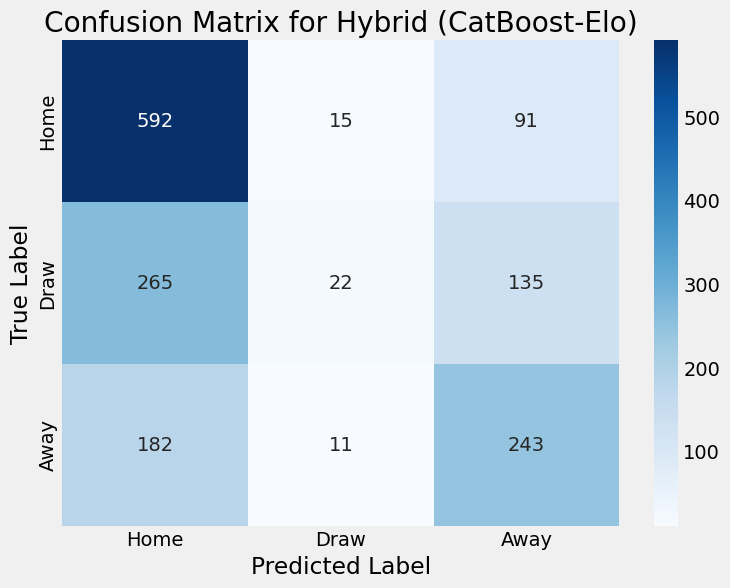


--- Confusion Matrix for CatBoost ---


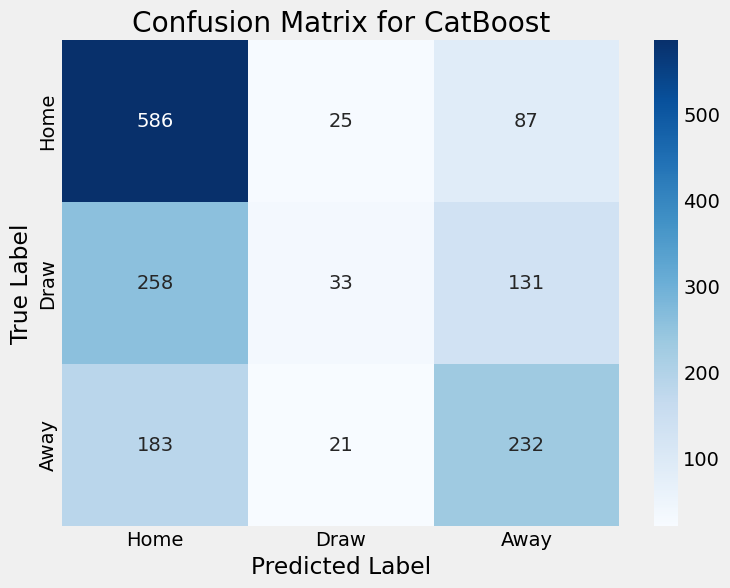


--- Confusion Matrix for Hybrid (XGBoost-Elo) ---


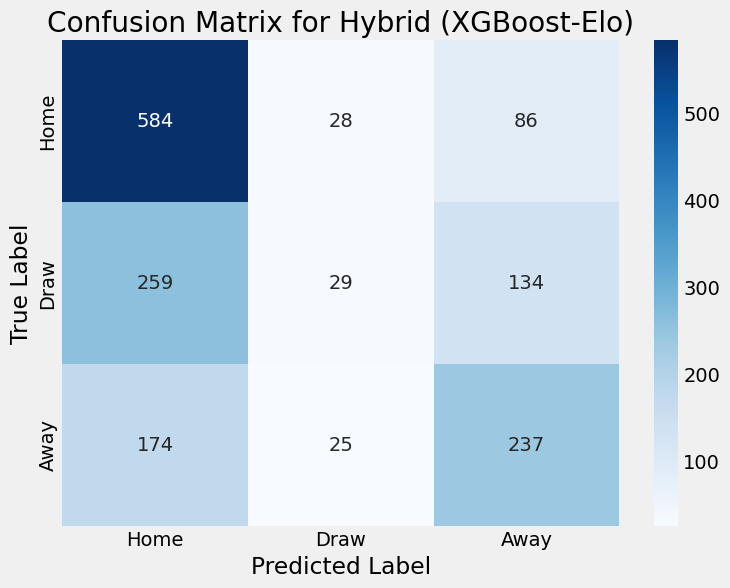

In [26]:
# Get the names of the top 3 models
top_3_model_names = comparison_df.head(3)['Model'].tolist()

# Map target labels to names for readability
target_names = ['Home', 'Draw', 'Away']

for model_name in top_3_model_names:
    print(f"\n--- Confusion Matrix for {model_name} ---")

    # Find the results entry for the current model
    model_results = next(res for res in results if res['Model'] == model_name)

    # Get predictions from probabilities
    model_preds = np.argmax(model_results['Probs'], axis=1)

    # Generate and plot the confusion matrix
    cm = confusion_matrix(y_test, model_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [27]:
import pickle
import json
import os

# 1. Identify the top 3 models
top_3_names = comparison_df.head(3)['Model'].tolist()
save_dir = "saved_models_pkl"

# Create a directory for models if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2. Hybrid weight mapping
hybrid_weights = {
    'Hybrid (XGBoost-Elo)': {'xgb_w': best_xgb_weight, 'elo_w': best_elo_weight_for_xgb},
    'Hybrid (Random Forest-Elo)': {'rf_w': best_rf_weight, 'elo_w': best_elo_weight_for_rf},
    'Hybrid (SVM-Elo)': {'svm_w': best_svm_weight, 'elo_w': best_elo_weight_for_svm},
    'Hybrid (LR-Elo)': {'lr_w': best_lr_weight, 'elo_w': best_elo_weight_for_lr}
}

print(f"📦 Saving top 3 models as .pkl to: '{save_dir}'\n")

for name in top_3_names:
    # Clean filename
    clean_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
    model_path = os.path.join(save_dir, f"{clean_name}.pkl")

    # CASE A: Save Base Models
    if name in models:
        with open(model_path, 'wb') as f:
            pickle.dump(models[name], f)
        print(f"✅ Saved Base Model: {model_path}")

    # CASE B: Save Hybrids
    elif 'Hybrid' in name:
        # Extract the base model part (e.g., "XGBoost" from "Hybrid (XGBoost-Elo)")
        base_key = next((k for k in models.keys() if k in name), None)

        if base_key:
            # Save the ML component
            with open(model_path, 'wb') as f:
                pickle.dump(models[base_key], f)

            # Save the weight component
            weights_path = os.path.join(save_dir, f"{clean_name}_weights.json")
            with open(weights_path, 'w') as f:
                json.dump(hybrid_weights.get(name, {}), f)

            print(f"✅ Saved Hybrid: {model_path} (+ weights JSON)")

print("\n✨ All set! Your .pkl files are ready in the local folder.")

📦 Saving top 3 models as .pkl to: 'saved_models_pkl'

✅ Saved Hybrid: saved_models_pkl\hybrid_catboost_elo.pkl (+ weights JSON)
✅ Saved Base Model: saved_models_pkl\catboost.pkl
✅ Saved Hybrid: saved_models_pkl\hybrid_xgboost_elo.pkl (+ weights JSON)

✨ All set! Your .pkl files are ready in the local folder.
